In [6]:
import sys
sys.path.append('../code')
import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, simulate, gaussian_tuning,
                                        StimSynapse, get_currents, IonotropicSynapse, initialize_params)
from memorycontext_dendrite_initialize_sweep import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [50]:
data_path = '/users/ntolley/data/ntolley/dendractor/memorycontext_dendrite'

dt = 0.025
t_max = 2000
time_vec = jnp.arange(0, t_max, dt)

# Used to reduce GPU memory (passed to simulate function)
levels = 2
time_points = t_max // dt + 2
checkpoints = [int(np.ceil(time_points**(1/levels))) for _ in range(levels)]

with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
    net, gid_ranges = pickle.load(f)

num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
num_cue_cells = len(gid_ranges['cue'])

parameters, _ = set_train_parameters(net, gid_ranges)
prior_dict = get_prior_dict()


theta_list = list()
error_list = list()
band_power_list = list()
num_flows = 4
for flow_idx in range(num_flows):
    print(f'Flow {flow_idx}')
    theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
    error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')
    band_power_avg = np.load(f'{data_path}/flow_band_power_{flow_idx}.npy')

    theta_list.append(theta)
    error_list.append(error)
    band_power_list.append(band_power_avg)

error_sort = np.argsort(error)
band_power_avg = np.array(band_power_avg)
band_power_sort = np.argsort(band_power_avg)[::-1]

init_sim_idx = error_sort[0]
# init_sim_idx = band_power_sort[0]


theta_array = np.load(f'{data_path}/theta_{num_flows - 1}.npy')
theta = theta_array[init_sim_idx, :]
# parameters = initialize_params(theta, parameters)


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 984. Total number of trainable parameters: 984


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 466. Total number of trainable parameters: 1450


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


...

/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 9485


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


Number of newly added trainable parameters: 50. Total number of trainable parameters: 9535
Number of newly added trainable parameters: 50. Total number of trainable parameters: 9585
Flow 0
Flow 1
Flow 2
Flow 3


/oscar/home/ntolley/Jones_Lab/dforce/externals/jaxley/jaxley/modules/base.py:1105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[-1, key] = np.nan


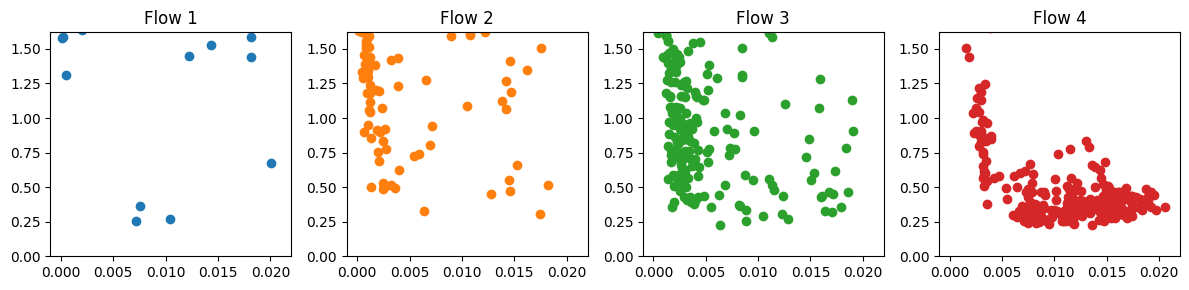

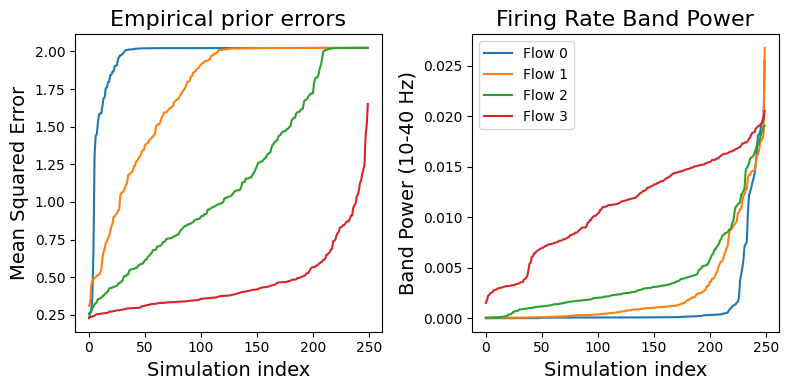

In [51]:
plt.figure(figsize=(3 * num_flows,3))
for idx in range(num_flows):
    plt.subplot(1,num_flows,idx+1)
    plt.scatter(band_power_list[idx], error_list[idx], color=f"C{idx}")
    plt.title(f'Flow {idx+1}')
    plt.xlim(-0.001, 0.022)
    plt.ylim(0, 1.62)
plt.tight_layout()

plt.figure(figsize=(8,4))
fontsize = 14
for idx in range(num_flows):
    plt.subplot(1,2,1)
    plt.plot(np.sort(error_list[idx]), label=f'Flow {idx}')
    plt.title('Empirical prior errors', fontsize=fontsize+2)
    plt.ylabel('Mean Squared Error', fontsize=fontsize)
    plt.xlabel('Simulation index', fontsize=fontsize)

    plt.subplot(1,2,2)
    plt.plot(np.sort(band_power_list[idx]), label=f'Flow {idx}')
    plt.xlabel('Simulation index', fontsize=fontsize)
    plt.ylabel('Band Power (10-40 Hz)', fontsize=fontsize)
    plt.title('Firing Rate Band Power', fontsize=fontsize+2)
plt.legend()
plt.tight_layout()

In [52]:
# Update with initialized parameters and get view of cell
for param_dict in parameters[:-2]:
    param_name, param_values = list(param_dict.items())[0]
    net.set(param_name, param_values[0]) # ignoring masking of connections since we just want the cell

# Set all synaptic conductances to zero
for param_name in net.edges.columns:
    if 'gS' in param_name:
        net.set(param_name, 0.0)

net.cell(gid_ranges['E']).set('axial_resistivity', 10.0)

In [53]:
t_max = 100
dt = 0.025
time_vec = np.arange(0, t_max, dt)

# soma_start = 1000
# dend_start = 2500

soma_start = 1000
dend_start = 2500

currents_soma = np.zeros(len(time_vec))
currents_soma[:] = -0.2
currents_soma[soma_start:soma_start+100] = 2

currents_dend = np.zeros(len(time_vec))
currents_dend[dend_start:dend_start+100] = 0.5

net.delete_stimuli()
net.cell(list(gid_ranges['E'])[0]).branch(3).comp(3).stimulate(currents_dend)
net.cell(list(gid_ranges['E'])[0]).branch(0).comp(0).stimulate(currents_soma)

net.delete_recordings()
net.cell(list(gid_ranges['E'])[0]).record('v')

Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 16 recordings. See `.recordings` for details.


In [54]:
s = jx.integrate(net, t_max=t_max)

Text(0, 0.5, 'Depth')

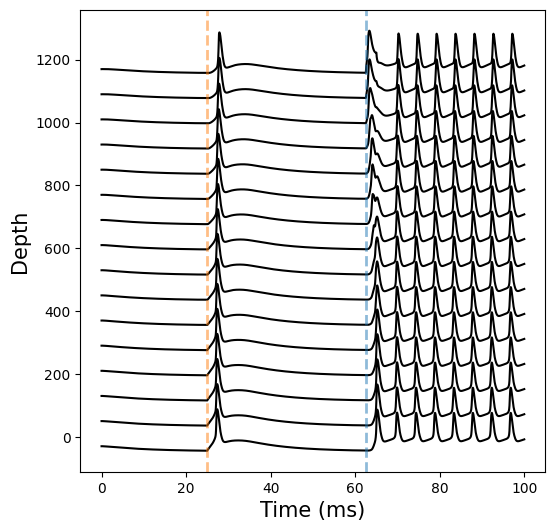

In [55]:
plt.figure(figsize=(6,6))
plt.plot(time_vec, s[0:16,:-1].T + np.arange(16) * 80 + 40, color='k')
plt.axvline(time_vec[soma_start], color='C1', linewidth=2, linestyle='--', alpha=0.5)
plt.axvline(time_vec[dend_start], color='C0', linewidth=2, linestyle='--', alpha=0.5)
plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('Depth', fontsize=15)